### Exercise 1 (Generated data)

In [39]:
import pandas as pd
import time
from itertools import combinations

In [40]:
# Dataset: 30 transactions
transactions = [
    ['ручка','тетрадь','карандаш'],
    ['ручка','тетрадь','ластик'],
    ['карандаш','линейка','ластик'],
    ['ручка','тетрадь','карандаш','ластик'],
    ['тетрадь','линейка'],
    ['ручка','карандаш'],
    ['ручка','тетрадь','линейка'],
    ['тетрадь','ластик','линейка'],
    ['ручка','тетрадь','карандаш'],
    ['карандаш','ластик'],
    ['ручка','тетрадь'],
    ['ручка','карандаш','линейка'],
    ['тетрадь','карандаш','ластик'],
    ['ручка','тетрадь','ластик'],
    ['ручка','линейка'],
    ['тетрадь','карандаш'],
    ['ручка','тетрадь','карандаш','линейка'],
    ['ластик','линейка'],
    ['ручка','тетрадь','карандаш'],
    ['тетрадь','ластик'],
    ['ручка','карандаш','ластик'],
    ['ручка','тетрадь','линейка'],
    ['карандаш','линейка'],
    ['ручка','тетрадь','карандаш','ластик'],
    ['тетрадь','линейка','ластик'],
    ['ручка','карандаш'],
    ['ручка','тетрадь','карандаш'],
    ['тетрадь','карандаш','линейка'],
    ['ручка','ластик'],
    ['ручка','тетрадь','карандаш'],
]

MIN_SUPPORT = 0.3
MIN_CONFIDENCE = 0.6

##### Algorithm apriori

In [41]:
from apriori_python import apriori

start = time.time()
freq_itemsets, rules_apriori = apriori(
    transactions,
    minSup=MIN_SUPPORT,
    minConf=MIN_CONFIDENCE
)
time_apriori = time.time() - start

print("=== Apriori (apriori_python) ===")
print(f"Time: {time_apriori:.4f} s\n")

print("Frequent itemsets:")
for k, v in freq_itemsets.items():
    print(f"  --- key = {k} ---")

    if isinstance(v, dict):
        # {itemset: support}
        for itemset, support in v.items():
            print(f"    {set(itemset)} : {float(support):.3f}")

    elif isinstance(v, (set, frozenset, list, tuple)):
        # a collection of itemsets (no support stored here)
        for itemset in v:
            # recompute support from transactions
            s = set(itemset)
            sup = sum(1 for t in transactions if s.issubset(set(t))) / len(transactions)
            print(f"    {s} : {sup:.3f}")

    elif isinstance(v, (int, float)):
        # flat dict: k is the itemset, v is support
        print(f"    {set(k)} : {float(v):.3f}")

    else:
        print(f"    (unhandled type {type(v)}): {v}")

print("\nRules:")
for rule in rules_apriori:
    # rule is a list: [antecedent, consequent]
    ant = set(rule[0]) if not isinstance(rule[0], set) else rule[0]
    con = set(rule[1]) if not isinstance(rule[1], set) else rule[1]

    n = len(transactions)
    ant_count  = sum(1 for t in transactions if ant.issubset(set(t)))
    con_count  = sum(1 for t in transactions if con.issubset(set(t)))
    both_count = sum(1 for t in transactions if (ant | con).issubset(set(t)))

    support    = both_count / n
    confidence = both_count / ant_count if ant_count else 0
    lift       = confidence / (con_count / n) if con_count else 0

    print(f"  {ant} -> {con} | sup={support:.3f}, conf={confidence:.3f}, lift={lift:.3f}")

=== Apriori (apriori_python) ===
Time: 0.0004 s

Frequent itemsets:
  --- key = 1 ---
    {'ручка'} : 0.633
    {'линейка'} : 0.400
    {'карандаш'} : 0.600
    {'ластик'} : 0.433
    {'тетрадь'} : 0.667
  --- key = 2 ---
    {'тетрадь', 'карандаш'} : 0.367
    {'ручка', 'тетрадь'} : 0.433
    {'ручка', 'карандаш'} : 0.400

Rules:
  {'карандаш'} -> {'тетрадь'} | sup=0.367, conf=0.611, lift=0.917
  {'ручка'} -> {'карандаш'} | sup=0.400, conf=0.632, lift=1.053
  {'тетрадь'} -> {'ручка'} | sup=0.433, conf=0.650, lift=1.026
  {'карандаш'} -> {'ручка'} | sup=0.400, conf=0.667, lift=1.053
  {'ручка'} -> {'тетрадь'} | sup=0.433, conf=0.684, lift=1.026


##### Efficient Apriori

In [42]:
from efficient_apriori import apriori as eff_apriori

start = time.time()
itemsets_eff, rules_eff = eff_apriori(
    transactions, min_support=MIN_SUPPORT, min_confidence=MIN_CONFIDENCE
)
time_eff = time.time() - start

print("=== Efficient Apriori ===")
print(f"Time: {time_eff:.4f} s")
for rule in rules_eff:
    print(rule)

=== Efficient Apriori ===
Time: 0.0004 s
{ручка} -> {карандаш} (conf: 0.632, supp: 0.400, lift: 1.053, conv: 1.086)
{карандаш} -> {ручка} (conf: 0.667, supp: 0.400, lift: 1.053, conv: 1.100)
{карандаш} -> {тетрадь} (conf: 0.611, supp: 0.367, lift: 0.917, conv: 0.857)
{тетрадь} -> {ручка} (conf: 0.650, supp: 0.433, lift: 1.026, conv: 1.048)
{ручка} -> {тетрадь} (conf: 0.684, supp: 0.433, lift: 1.026, conv: 1.056)


##### FPGrowth

In [43]:
from fpgrowth_py import fpgrowth

start = time.time()
freq_itemsets, rules_fp = fpgrowth(
    transactions, minSupRatio=MIN_SUPPORT, minConf=MIN_CONFIDENCE
)
time_fp = time.time() - start

print("=== FPGrowth ===")
print(f"Time: {time_fp:.4f} s")
for rule in rules_fp:
    print(rule)

=== FPGrowth ===
Time: 0.0007 s
[{'карандаш'}, {'тетрадь'}, 0.6111111111111112]
[{'ручка'}, {'карандаш'}, 0.631578947368421]
[{'карандаш'}, {'ручка'}, 0.6666666666666666]
[{'ручка'}, {'тетрадь'}, 0.6842105263157895]
[{'тетрадь'}, {'ручка'}, 0.65]


##### Metrics for Rules (support, confidence, lift)

In [44]:
def compute_metrics(transactions, rule):
    """
    Accepts either:
      - an efficient_apriori Rule object (has .lhs, .rhs, .support, .confidence, .lift)
      - a (antecedent, consequent) tuple/list of iterables
    Returns: (support, confidence, lift)
    """
    # Case 1: efficient_apriori Rule object
    if hasattr(rule, 'lhs') and hasattr(rule, 'rhs'):
        ant = set(rule.lhs)
        con = set(rule.rhs)
    # Case 2: plain tuple/list (ant, con)
    elif isinstance(rule, (tuple, list)) and len(rule) == 2:
        ant, con = set(rule[0]), set(rule[1])
    else:
        raise TypeError(f"Unsupported rule format: {type(rule)} -> {rule}")

    n = len(transactions)
    ant_count  = sum(1 for t in transactions if ant.issubset(set(t)))
    con_count  = sum(1 for t in transactions if con.issubset(set(t)))
    both_count = sum(1 for t in transactions if (ant | con).issubset(set(t)))

    support    = both_count / n
    confidence = both_count / ant_count if ant_count else 0
    lift       = confidence / (con_count / n) if con_count else 0
    return support, confidence, lift

print("\n--- Rules with confidence >= 0.6 ---")
for rule in rules_eff:
    sup, conf, lift = compute_metrics(transactions, rule)
    if conf >= 0.6:
        # Rule object → use .lhs / .rhs
        ant = set(rule.lhs) if hasattr(rule, 'lhs') else set(rule[0])
        con = set(rule.rhs) if hasattr(rule, 'rhs') else set(rule[1])
        print(f"  {ant} -> {con} | sup={sup:.3f}, conf={conf:.3f}, lift={lift:.3f}")

print("\n--- Rules with confidence >= 0.8 ---")
for rule in rules_eff:
    sup, conf, lift = compute_metrics(transactions, rule)
    if conf >= 0.8:
        ant = set(rule.lhs) if hasattr(rule, 'lhs') else set(rule[0])
        con = set(rule.rhs) if hasattr(rule, 'rhs') else set(rule[1])
        print(f"  {ant} -> {con} | sup={sup:.3f}, conf={conf:.3f}, lift={lift:.3f}")


--- Rules with confidence >= 0.6 ---
  {'ручка'} -> {'карандаш'} | sup=0.400, conf=0.632, lift=1.053
  {'карандаш'} -> {'ручка'} | sup=0.400, conf=0.667, lift=1.053
  {'карандаш'} -> {'тетрадь'} | sup=0.367, conf=0.611, lift=0.917
  {'тетрадь'} -> {'ручка'} | sup=0.433, conf=0.650, lift=1.026
  {'ручка'} -> {'тетрадь'} | sup=0.433, conf=0.684, lift=1.026

--- Rules with confidence >= 0.8 ---


##### Comparison and Diagram

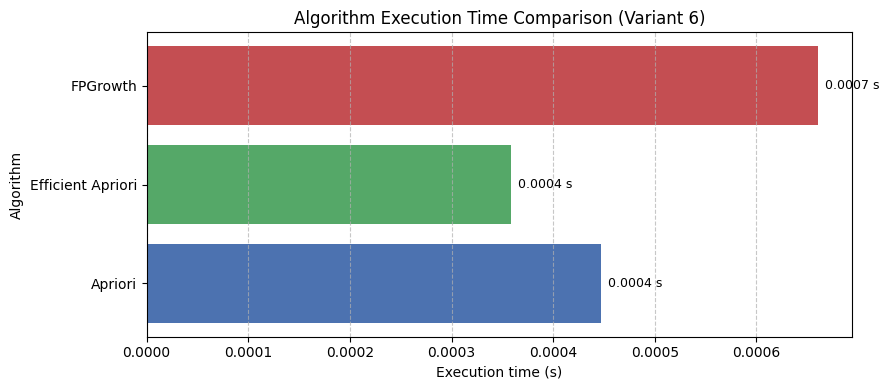

In [45]:
import matplotlib.pyplot as plt

algorithms = ['Apriori', 'Efficient Apriori', 'FPGrowth']
times = [time_apriori, time_eff, time_fp]

# Horizontal bar chart: categories on Y, time on X
plt.figure(figsize=(9, 4))
bars = plt.barh(algorithms, times, color=['#4C72B0', '#55A868', '#C44E52'])

plt.xlabel('Execution time (s)')          # time on X-axis
plt.ylabel('Algorithm')                   # algorithms on Y-axis
plt.title('Algorithm Execution Time Comparison (Variant 6)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate each bar with its value
for bar, t in zip(bars, times):
    plt.text(t + max(times) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{t:.4f} s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150)
plt.show()

##### Visualization 

/tmp/ipykernel_30728/3397882301.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


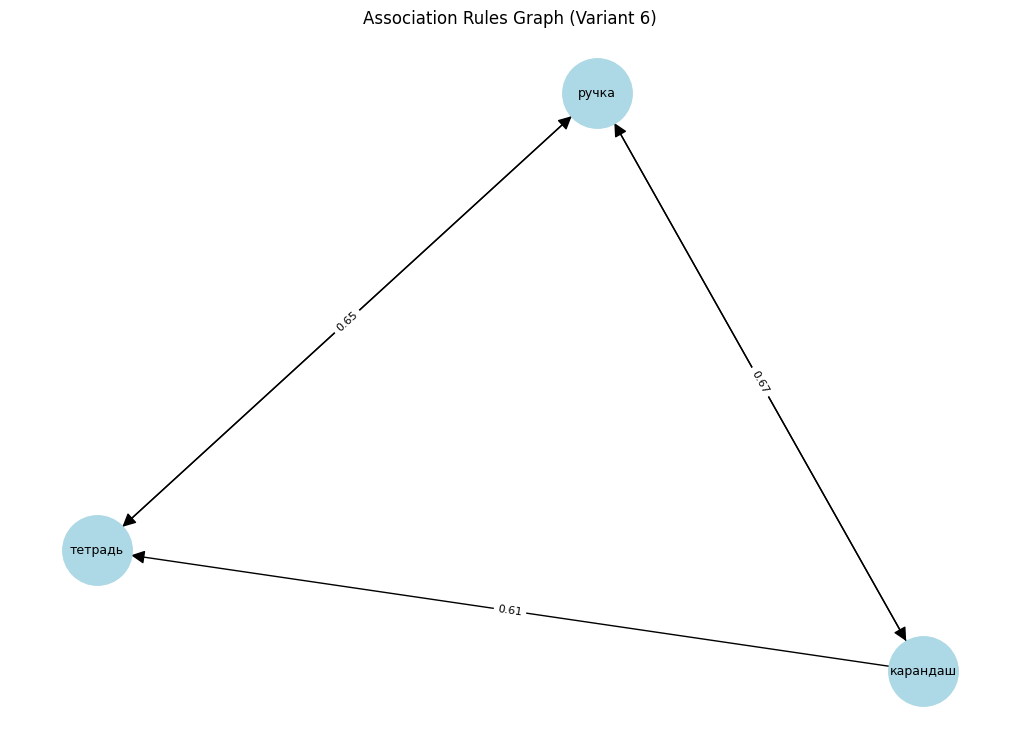

In [46]:
# pip install mlxtend networkx matplotlib
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as ml_apriori, association_rules
import networkx as nx

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

frequent = ml_apriori(df, min_support=MIN_SUPPORT, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=MIN_CONFIDENCE)

G = nx.DiGraph()
for _, r in rules.iterrows():
    G.add_edge(', '.join(r['antecedents']), ', '.join(r['consequents']),
               weight=r['confidence'])

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2500, font_size=9, arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={k: f"{v:.2f}" for k,v in edge_labels.items()}, font_size=8)
plt.title('Association Rules Graph (Variant 6)')
plt.tight_layout()
plt.savefig('rules_graph.png', dpi=150)
plt.show()

### Exercise 2 (from repository)

In [47]:
import pandas as pd
import numpy as np
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as ml_apriori, association_rules

# Load the dataset
df = pd.read_csv('BreadBasket_DMS.csv')
print(df.head())
print(df.shape)
# Expected shape: (20507, 4) approximately

         Date      Time  Transaction           Item
0  2016-10-30  09:58:11            1          Bread
1  2016-10-30  10:05:34            2   Scandinavian
2  2016-10-30  10:05:34            2   Scandinavian
3  2016-10-30  10:07:57            3  Hot chocolate
4  2016-10-30  10:07:57            3            Jam
(21293, 4)


In [48]:
# Remove invalid items (there are known 'NONE' entries)
df = df[df['Item'] != 'NONE']

# Group items by Transaction ID to create baskets
baskets = df.groupby('Transaction')['Item'].apply(list).tolist()

print(f"Total baskets: {len(baskets)}")
print(f"Sample basket: {baskets[0]}")

Total baskets: 9465
Sample basket: ['Bread']


##### Algorithm Apriori

In [49]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as ml_apriori, association_rules

# One-hot encode the baskets
te = TransactionEncoder()
te_array = te.fit(baskets).transform(baskets)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

# Run Apriori
start = time.time()
frequent_itemsets_ml = ml_apriori(df_encoded, min_support=0.005, use_colnames=True)
time_apriori_ml = time.time() - start

# Generate rules at confidence 0.6
rules_ml_60 = association_rules(frequent_itemsets_ml, metric="confidence", min_threshold=0.6)
# Generate rules at confidence 0.8
rules_ml_80 = association_rules(frequent_itemsets_ml, metric="confidence", min_threshold=0.8)

print(f"mlxtend Apriori time: {time_apriori_ml:.4f}s")
print(f"Rules at 60% confidence: {len(rules_ml_60)}")
print(f"Rules at 80% confidence: {len(rules_ml_80)}")

mlxtend Apriori time: 0.1300s
Rules at 60% confidence: 4
Rules at 80% confidence: 1


##### Algorithm Efficient Apriori

In [50]:
from efficient_apriori import apriori as efficient_apriori

start = time.time()
itemsets_eff, rules_eff = efficient_apriori(
    baskets, min_support=0.005, min_confidence=0.6
)
time_eff = time.time() - start

print(f"Efficient Apriori time: {time_eff:.4f}s")
print(f"Rules: {len(rules_eff)}")

Efficient Apriori time: 0.0192s
Rules: 4


##### FPGrowth

In [51]:
from fpgrowth_py import fpgrowth

start = time.time()
freq_itemsets_fp, rules_fp = fpgrowth(
    baskets, minSupRatio=0.005, minConf=0.6
)
time_fp = time.time() - start

print(f"FPGrowth time: {time_fp:.4f}s")
print(f"Rules: {len(rules_fp)}")

FPGrowth time: 1.8227s
Rules: 9


##### Computing Rule Metrics (Support, Confidence, Lift)

In [52]:
def compute_metrics(baskets, antecedent, consequent):
    """Compute support, confidence, and lift for a rule."""
    n = len(baskets)
    ant_count = sum(1 for b in baskets if set(antecedent).issubset(set(b)))
    both_count = sum(1 for b in baskets if (set(antecedent) | set(consequent)).issubset(set(b)))
    con_count = sum(1 for b in baskets if set(consequent).issubset(set(b)))
    
    support = both_count / n
    confidence = both_count / ant_count if ant_count > 0 else 0
    lift = confidence / (con_count / n) if con_count > 0 else 0
    return support, confidence, lift

# Example: display rules from mlxtend with metrics
print(rules_ml_60[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

             antecedents consequents   support  confidence      lift
0     (Keeping It Local)    (Coffee)  0.005388    0.809524  1.692169
1                (Salad)    (Coffee)  0.006550    0.626263  1.309094
2                (Toast)    (Coffee)  0.023666    0.704403  1.472431
3  (Hot chocolate, Cake)    (Coffee)  0.006867    0.601852  1.258067


##### Time comparison

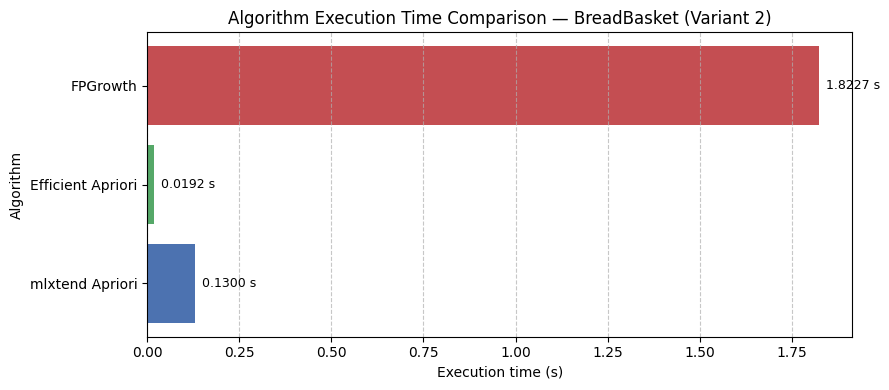

In [53]:
import matplotlib.pyplot as plt

algorithms = ['mlxtend Apriori', 'Efficient Apriori', 'FPGrowth']
times = [time_apriori_ml, time_eff, time_fp]

plt.figure(figsize=(9, 4))
bars = plt.barh(algorithms, times, color=['#4C72B0', '#55A868', '#C44E52'])

plt.xlabel('Execution time (s)')
plt.ylabel('Algorithm')
plt.title('Algorithm Execution Time Comparison — BreadBasket (Variant 2)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar, t in zip(bars, times):
    plt.text(t + max(times) * 0.01, bar.get_y() + bar.get_height() / 2,
             f'{t:.4f} s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_breadbasket.png', dpi=150)
plt.show()

##### Visualization of association rules

/home/nyathi/.local/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:304: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)
/tmp/ipykernel_30728/2835153841.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


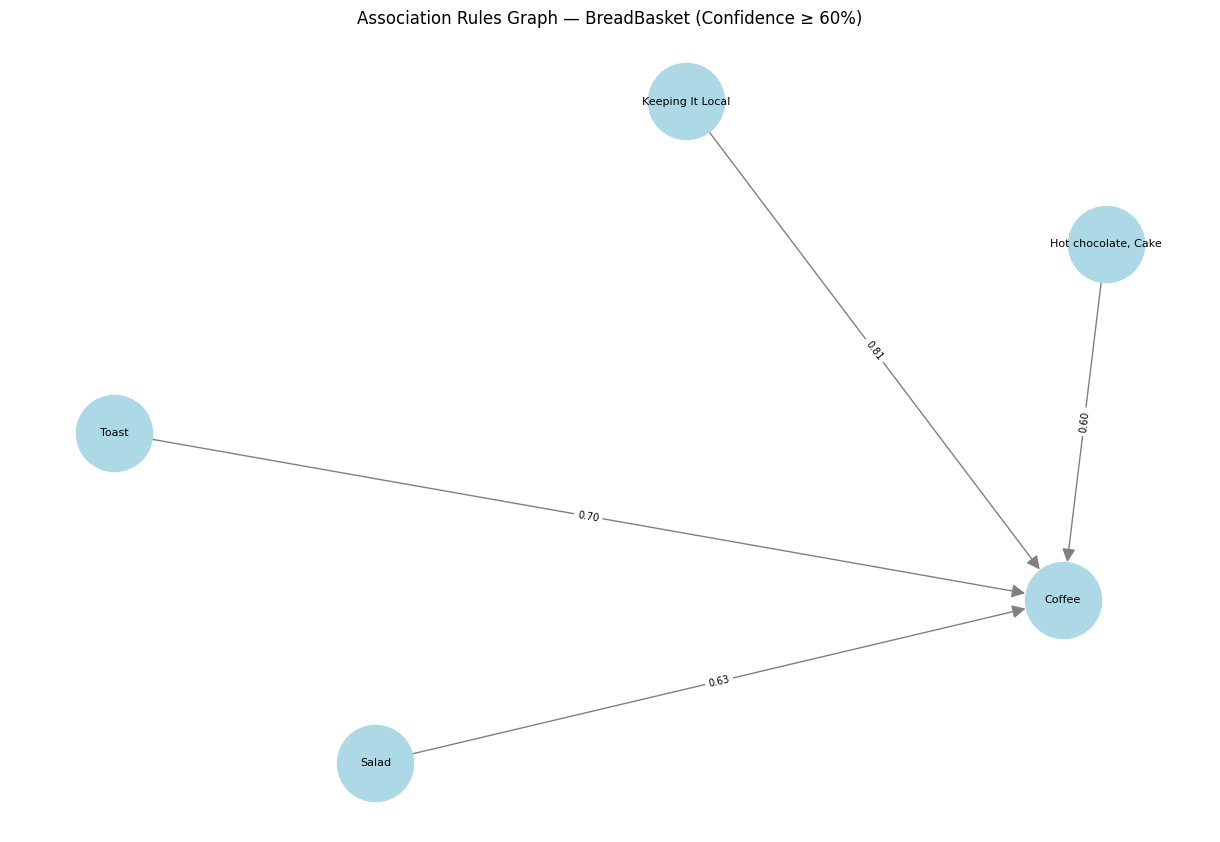

In [54]:
import networkx as nx

# Use rules at 60% confidence for visualization
G = nx.DiGraph()
for _, r in rules_ml_60.iterrows():
    ant = ', '.join(list(r['antecedents']))
    con = ', '.join(list(r['consequents']))
    G.add_edge(ant, con, weight=r['confidence'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=2)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=3000, font_size=8, arrowsize=20, edge_color='gray')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos,
    edge_labels={k: f"{v:.2f}" for k, v in edge_labels.items()}, font_size=7)
plt.title('Association Rules Graph — BreadBasket (Confidence ≥ 60%)')
plt.tight_layout()
plt.savefig('rules_graph_breadbasket.png', dpi=150)
plt.show()